In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from matplotlib import colors
import numpy as np
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
import datetime
from plotly.offline import init_notebook_mode, iplot
import plotly.offline as py
import plotly.express as px
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc

In [5]:
import pandas as pd

# Example of reading a CSV file
file_path = '/content/sample_data/california_housing_train.csv'
df = pd.read_csv(file_path)

print(f"Successfully read file: {file_path}")
print(df.head())

Successfully read file: /content/sample_data/california_housing_train.csv
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


In [6]:
def check(df):
    l=[]
    columns=df.columns
    for col in columns:
        dtypes=df[col].dtypes
        nunique=df[col].nunique()
        sum_null=df[col].isnull().sum()
        l.append([col,dtypes,nunique,sum_null])
    df_check=pd.DataFrame(l)
    df_check.columns=['column','dtypes','nunique','sum_null']
    return df_check
check(df)

,column,dtypes,nunique,sum_null
0,longitude,float64,827,0
1,latitude,float64,840,0
2,housing_median_age,float64,52,0
3,total_rooms,float64,5533,0
4,total_bedrooms,float64,1848,0
5,population,float64,3683,0
6,households,float64,1740,0
7,median_income,float64,11175,0
8,median_house_value,float64,3694,0


In [8]:
incomeNulls = pd.isnull(df["median_income"])
df[incomeNulls]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value


In [9]:
df1=df.dropna()
df1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [17]:
# df1['Dt_Customer']=pd.to_datetime(df1['Dt_Customer'])
# dates = []
# for i in df1["Dt_Customer"]:
#     i = i.date()
#     dates.append(i)
# days = []
# d1 = max(dates) #taking it to be the newest customer
# for i in dates:
#     delta = d1 - i
#     days.append(delta)
# df1["Customer_For"] = days
# df1["Customer_For"] = pd.to_numeric(df1["Customer_For"], errors="coerce")
# print("Total categories in the feature Marital_Status:\n", df1["Marital_Status"].value_counts(), "\n")
# print("Total categories in the feature Education:\n", df1["Education"].value_counts())

### Demonstrating Customer Feature Engineering with Sample Data

Since the `df1` DataFrame (California Housing data) does not contain columns like `Dt_Customer`, `Year_Birth`, `Marital_Status`, or `Education`, I will create a sample DataFrame (`customer_df`) with these columns to demonstrate the logic you were trying to implement. This code will successfully run on `customer_df`.

In [21]:
import datetime

# Create a sample DataFrame with customer-related columns
customer_data = {
    'ID': range(1, 11),
    'Year_Birth': [1985, 1970, 1992, 1965, 1988, 1975, 1990, 1980, 1968, 1995],
    'Education': ['Graduation', 'PhD', 'Master', 'Graduation', 'PhD', '2n Cycle', 'Master', 'Graduation', 'PhD', 'Basic'],
    'Marital_Status': ['Married', 'Single', 'Married', 'Divorced', 'Together', 'Single', 'Married', 'Together', 'Married', 'Single'],
    'Dt_Customer': ['2012-05-01', '2014-03-15', '2013-11-20', '2015-01-10', '2016-07-22', '2012-09-05', '2014-04-30', '2013-02-18', '2015-12-01', '2016-01-25'],
    'MntWines': [100, 250, 50, 300, 150, 200, 75, 270, 120, 60],
    'MntFruits': [10, 20, 5, 30, 15, 25, 8, 28, 12, 6],
    'MntMeatProducts': [50, 100, 25, 150, 75, 90, 30, 130, 60, 20],
    'MntFishProducts': [5, 10, 2, 15, 7, 12, 3, 14, 6, 1],
    'MntSweetProducts': [8, 15, 3, 20, 10, 18, 4, 17, 9, 2],
    'MntGoldProds': [12, 25, 6, 35, 18, 22, 7, 30, 15, 5]
}
customer_df = pd.DataFrame(customer_data)
display(customer_df.head())

,ID,Year_Birth,Education,Marital_Status,Dt_Customer,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,1,1985,Graduation,Married,2012-05-01,100,10,50,5,8,12
1,2,1970,PhD,Single,2014-03-15,250,20,100,10,15,25
2,3,1992,Master,Married,2013-11-20,50,5,25,2,3,6
3,4,1965,Graduation,Divorced,2015-01-10,300,30,150,15,20,35
4,5,1988,PhD,Together,2016-07-22,150,15,75,7,10,18


---

In [35]:
import datetime

# Code from your original cell S2oUei_VOUdZ, applied to customer_df
customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'])
dates = []
for i in customer_df["Dt_Customer"]:
    i = i.date()
    dates.append(i)
days = []
d1 = max(dates) #taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta.days) # Extract days directly from timedelta
customer_df["Customer_For"] = days
# No need for pd.to_numeric here as .days already returns a number

print("Total categories in the feature Marital_Status:\n", customer_df["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", customer_df["Education"].value_counts())

display(customer_df.head())

Total categories in the feature Marital_Status:
 Marital_Status
Married     4
Single      3
Together    2
Divorced    1
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    3
PhD           3
Master        2
2n Cycle      1
Basic         1
Name: count, dtype: int64


,ID,Year_Birth,Age,Education,Marital_Status,Living_With,Dt_Customer,expenses,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Customer_For
0,1,1985,41,Graduation,Married,2,2012-05-01,185,100,10,50,5,8,12,1543
1,2,1970,56,PhD,Single,1,2014-03-15,420,250,20,100,10,15,25,860
2,3,1992,34,Master,Married,2,2013-11-20,91,50,5,25,2,3,6,975
3,4,1965,61,Graduation,Divorced,1,2015-01-10,550,300,30,150,15,20,35,559
4,5,1988,38,PhD,Together,2,2016-07-22,275,150,15,75,7,10,18,0


In [23]:
# Code from your original cell JvrTuk1UOUbR, applied to customer_df
age = datetime.date.today().year - customer_df['Year_Birth']
customer_df.insert(2, 'Age', age)
expenses = customer_df["MntWines"] + customer_df["MntFruits"] + customer_df["MntMeatProducts"] + customer_df["MntFishProducts"] + customer_df["MntSweetProducts"] + customer_df["MntGoldProds"]
customer_df.insert(6, 'expenses', expenses)
Living_With = customer_df["Marital_Status"].replace({"Married":2, "Together":2, "Absurd":1, "Widow":1, "YOLO":1, "Divorced":1,'Single':1,'Alone':1})
customer_df.insert(5, 'Living_With', Living_With)
customer_df['Living_With'] = customer_df['Living_With'].astype(int)

display(customer_df.head())

/tmp/ipykernel_764/2410066040.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,ID,Year_Birth,Age,Education,Marital_Status,Living_With,Dt_Customer,expenses,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Customer_For
0,1,1985,41,Graduation,Married,2,2012-05-01,185,100,10,50,5,8,12,133315200000000000
1,2,1970,56,PhD,Single,1,2014-03-15,420,250,20,100,10,15,25,74304000000000000
2,3,1992,34,Master,Married,2,2013-11-20,91,50,5,25,2,3,6,84240000000000000
3,4,1965,61,Graduation,Divorced,1,2015-01-10,550,300,30,150,15,20,35,48297600000000000
4,5,1988,38,PhD,Together,2,2016-07-22,275,150,15,75,7,10,18,0


### Visualizing Customer Data

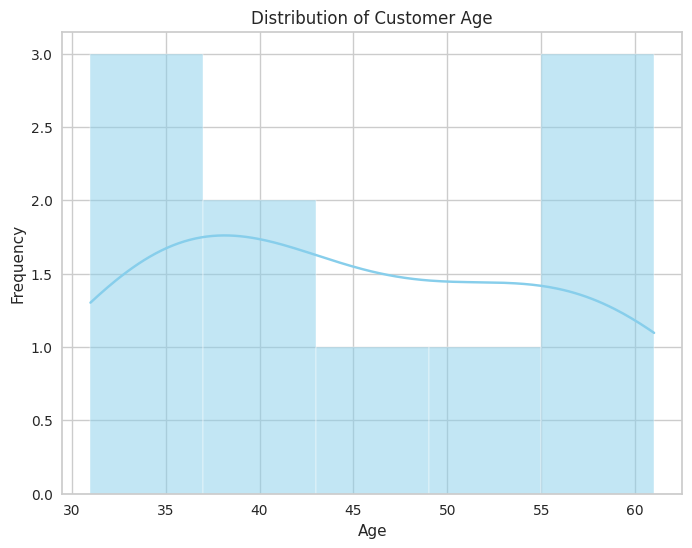

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style('whitegrid')


plt.figure(figsize=(8, 6))
sns.histplot(customer_df['Age'], kde=True, bins=5, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

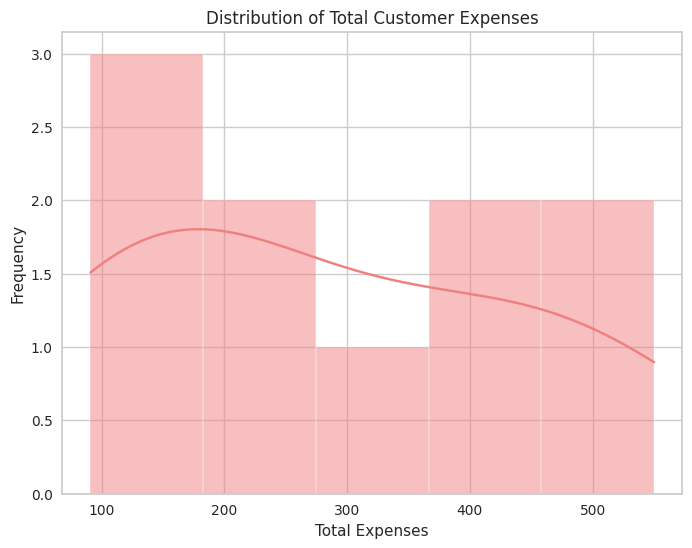

In [29]:

plt.figure(figsize=(8, 6))
sns.histplot(customer_df['expenses'], kde=True, bins=5, color='lightcoral')
plt.title('Distribution of Total Customer Expenses')
plt.xlabel('Total Expenses')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_764/1965177876.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




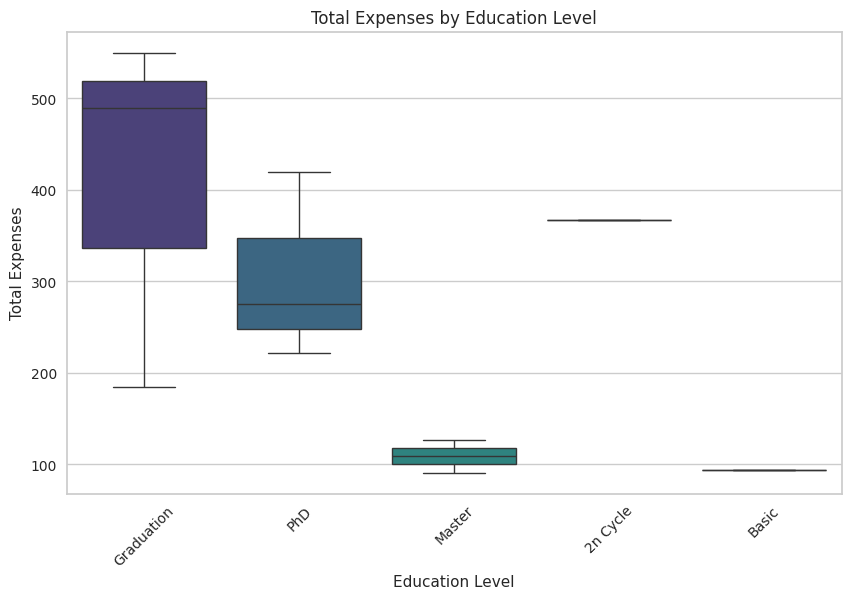

In [30]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Education', y='expenses', data=customer_df, palette='viridis')
plt.title('Total Expenses by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Total Expenses')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_764/4090690334.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




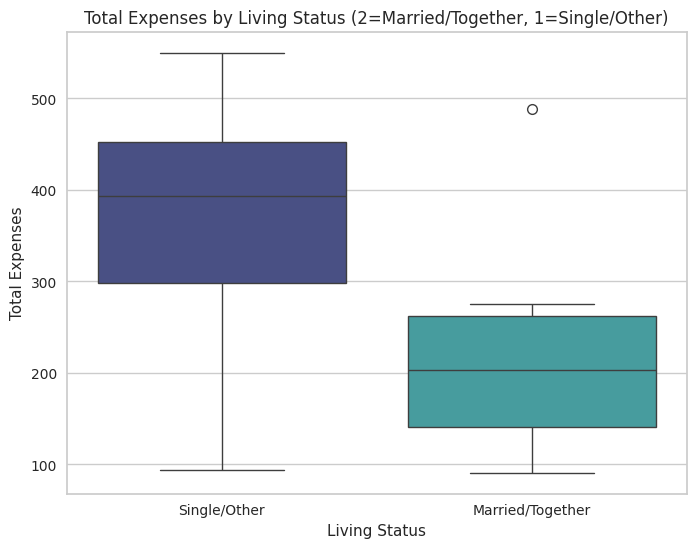

In [31]:

plt.figure(figsize=(8, 6))
sns.boxplot(x='Living_With', y='expenses', data=customer_df, palette='mako')
plt.title('Total Expenses by Living Status (2=Married/Together, 1=Single/Other)')
plt.xlabel('Living Status')
plt.ylabel('Total Expenses')
plt.xticks([0, 1], ['Single/Other', 'Married/Together']) # Custom labels
plt.show()

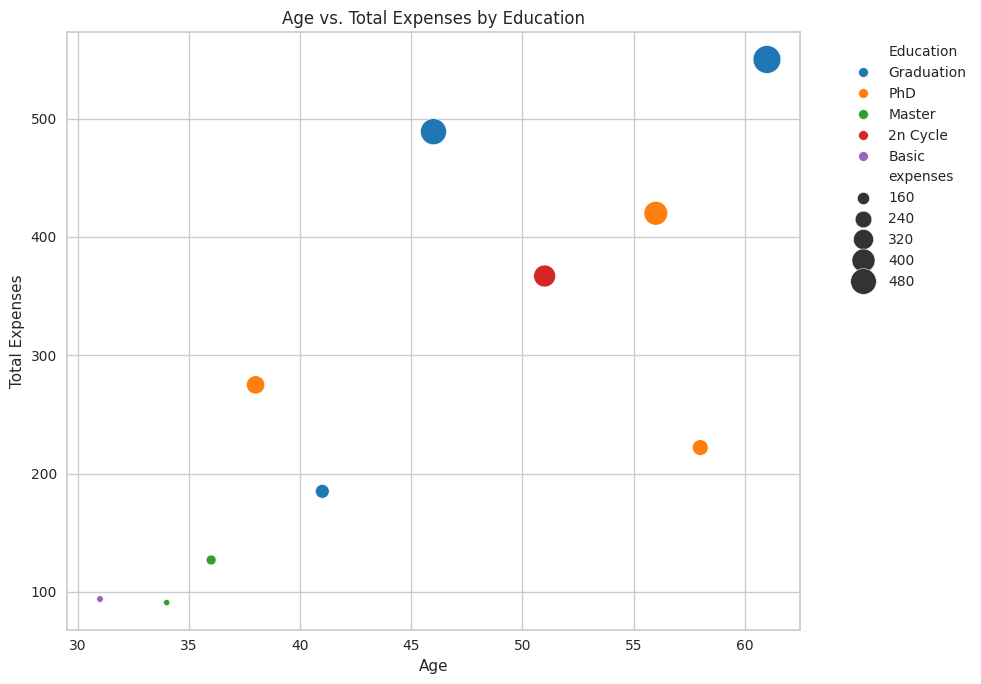

In [33]:

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age', y='expenses', hue='Education', data=customer_df, size='expenses', sizes=(20, 400), palette='tab10')
plt.title('Age vs. Total Expenses by Education')
plt.xlabel('Age')
plt.ylabel('Total Expenses')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

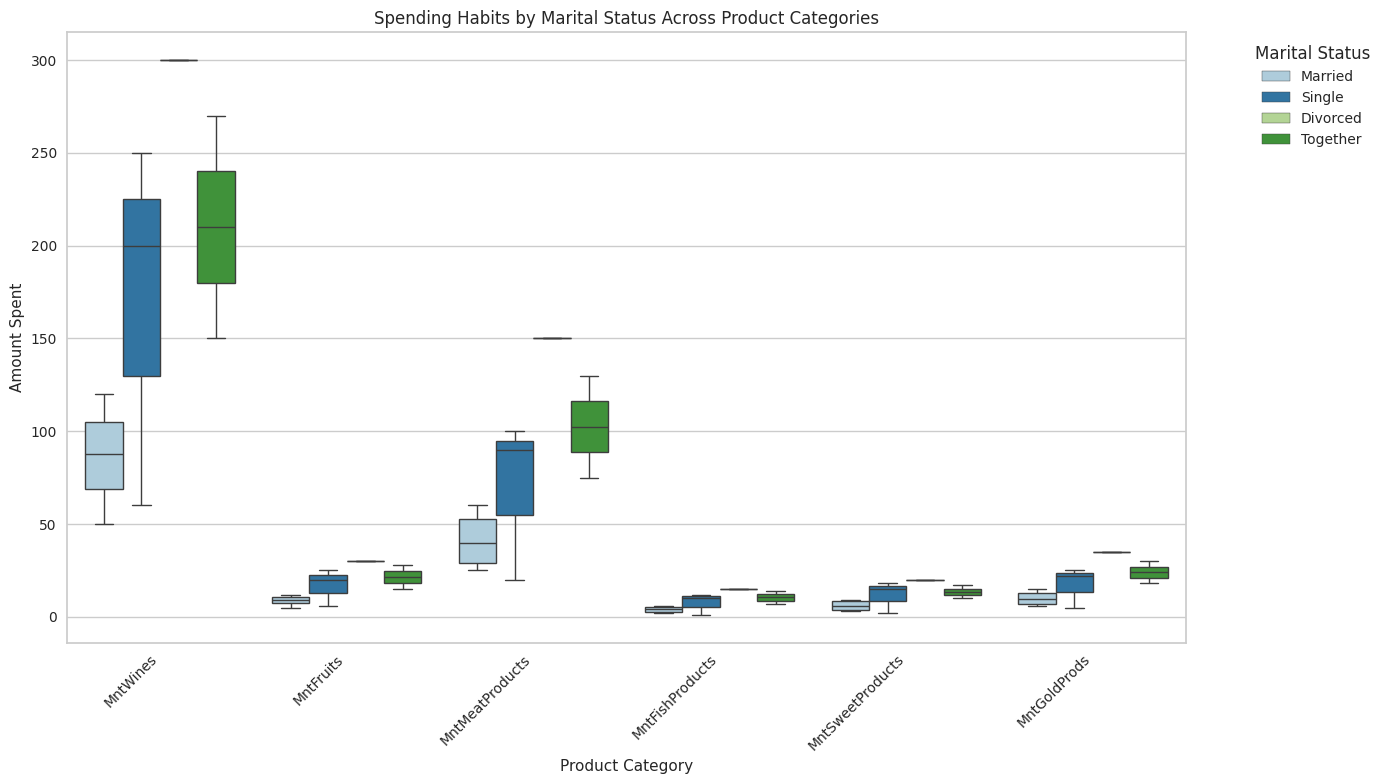

In [34]:

spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
customer_df_melted = customer_df.melt(id_vars=['Marital_Status'], value_vars=spending_cols, var_name='Product_Category', value_name='Amount_Spent')

plt.figure(figsize=(14, 8))
sns.boxplot(x='Product_Category', y='Amount_Spent', hue='Marital_Status', data=customer_df_melted, palette='Paired')
plt.title('Spending Habits by Marital Status Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Amount Spent')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Marital Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()